# Phase 4: Expirementation with Kronecker Sequences

First we must import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import time
import matplotlib.ticker as mtick
from collections import Counter
import itertools
from dataclasses import dataclass, asdict



# Import Calculations for Zaremba Index
from math_help import rho_box1_numpy, rho_box_bruteforce, rho_box_lyness, rho_3d_lyness, rho_3d_lyness_corrected, rho_4d_lyness_corrected, rho_5d_lyness_corrected,  generate_optimized_g_vectors_3d, rho_4d_lyness, rho_5d_lyness, generate_optimized_g_vectors_4d, generate_optimized_g_vectors_5d

# Import Dataframe Helper
from experiment import bound_sufficiency_df

From the old study we know that - $ \rho_d(N, \alpha) \ge \frac{cN}{\psi(N)^{d-1}}$ : Is more of a theoretical lower-bound scale / existence-type benchmark

Our goal is to:
- Understand the distribution of $\rho_d(N,g)$
- Understand how the worst, median, and possibly upper quantiles behave w/ N
- Compare empirical behaviour against theoretical scaling
- Do this in 3D, 4D, and 5D

$$\rho_d(N, \alpha) \ge \frac{cN}{\psi(N)^{d-1}}$$

First let's setup the basic helper functions that are going to be using for this experiment


First lets find the distribution of rho values throgh prime N's.
Then we will also comapre this to the bound  
$$\rho_d(N, \alpha) \ge \frac{cN}{\psi(N)^{d-1}}$$

In [4]:
DELTA = 0.5   # any δ > 0 works; 0.5 is a common choice
C = 1.0  # placeholder — treat the bound as up to a constant factor

def psi(N: int) -> float:
    """ψ(N) = (log N)(log log N)^(1+δ) for N >= 3, else 1"""
    if N < 3:
        return 1.0
    log_N = np.log(N)
    log_log_N = np.log(log_N)
    return log_N * (log_log_N ** (1 + DELTA))


def rho_lower_bound(N: int, d: int) -> float:
    """Lower bound: ρ_d(N, α) >= cN / ψ(N)^(d-1)"""
    return (C * N) / (psi(N) ** (d - 1))

In [2]:
def analyze_rho_distribution(N_values, d=3):
    """
    Calculates the rho values for optimized g vectors, accounting for symmetry weights.
    Returns a summary DataFrame with quartiles and a dictionary of raw data for histograms.
    """
    stats_list = []
    distribution_data = {} 
    
    print(f"Starting Rho Distribution Analysis for {d}D...\n")
    
    for N in N_values:
        rho_values = []
        
        # Iterate through the optimized search space
        # Using 3D as the default based on the previous cells
        for g_vector, weight in generate_optimized_g_vectors_3d(N):
            alpha_vector = (g_vector[1] / N, g_vector[2] / N)
            actual_rho, _ = rho_3d_lyness_corrected(N, alpha_vector)
            
            # Crucial: Account for symmetry! 
            # Multiply the single observation by its weight to maintain true distribution density
            rho_values.extend([actual_rho] * weight) 
            
        # Convert to numpy array for fast statistical operations
        rho_array = np.array(rho_values)
        
        # Store raw data in a DataFrame for easy histogram plotting later
        distribution_data[N] = pd.DataFrame({'rho': rho_array})
        
        # Calculate percentiles and bounds
        min_rho = np.min(rho_array)
        q1 = np.percentile(rho_array, 25)
        median_rho = np.median(rho_array) # The exact bound where 50% pass
        q3 = np.percentile(rho_array, 75)
        max_rho = np.max(rho_array)
        
        stats_list.append({
            'N': N,
            'Min': min_rho,
            '25th Percentile (Q1)': q1,
            'Median (50% Bound)': median_rho,
            '75th Percentile (Q3)': q3,
            'Max': max_rho,
            'Total Vectors': len(rho_array)
        })
        
        print(f"--- N = {N} ---")
        print(f"Empirical 50% Bound (Median): {median_rho:.4f}")
        
    stats_df = pd.DataFrame(stats_list)
    return stats_df, distribution_data

# Define the prime N values you want to test
N_targets = [101, 251, 503, 1009]

# Run the analysis
distribution_stats_df, raw_distributions = analyze_rho_distribution(N_targets)

# Display the summary table
display(distribution_stats_df)

Starting Rho Distribution Analysis for 3D...

--- N = 101 ---
Empirical 50% Bound (Median): 4.0000
--- N = 251 ---
Empirical 50% Bound (Median): 6.0000
--- N = 503 ---
Empirical 50% Bound (Median): 10.0000
--- N = 1009 ---
Empirical 50% Bound (Median): 16.0000


,N,Min,25th Percentile (Q1),Median (50% Bound),75th Percentile (Q3),Max,Total Vectors
0,101,1.0,2.0,4.0,5.0,10.0,10000
1,251,1.0,4.0,6.0,9.0,20.0,62500
2,503,1.0,6.0,10.0,15.0,42.0,252004
3,1009,1.0,9.0,16.0,24.0,74.0,1016064


In [9]:
rows = []
for N, df in raw_distributions.items():
    lb = rho_lower_bound(N, d=3)
    count_above = (df['rho'] >= lb).sum()
    count_below = (df['rho'] < lb).sum()
    total = len(df)
    rows.append({
        'N': N,
        'Lower Bound': round(lb, 4),
        'Count Above': count_above,
        '% Above': round(100 * count_above / total, 2),
        'Count Below': count_below,
        '% Below': round(100 * count_below / total, 2),
        'Total': total,
    })

bound_check_df = pd.DataFrame(rows)
display(bound_check_df)


,N,Lower Bound,Count Above,% Above,Count Below,% Below,Total
0,101,1.3257,9024,90.24,976,9.76,10000
1,251,1.6460,60024,96.04,2476,3.96,62500
2,503,2.1285,235224,93.34,16780,6.66,252004
3,1009,2.9158,982080,96.66,33984,3.34,1016064


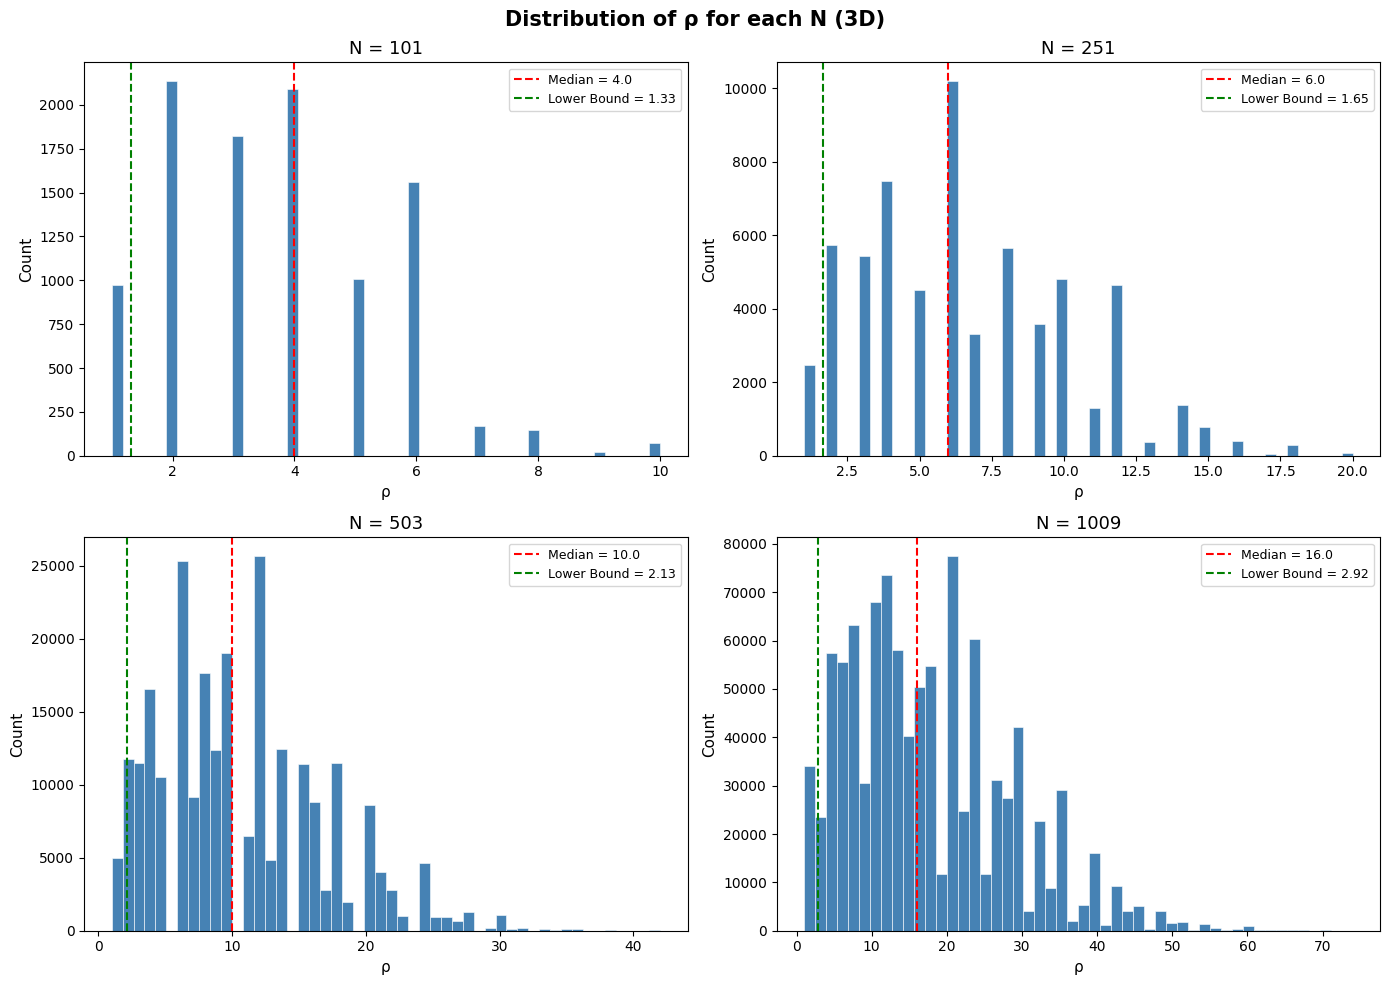

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (N, df) in enumerate(raw_distributions.items()):
    ax = axes[i]
    rho_vals = df['rho']
    lb = rho_lower_bound(N, d=3)

    ax.hist(rho_vals, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.axvline(rho_vals.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median = {rho_vals.median():.1f}')
    ax.axvline(lb, color='green', linestyle='--', linewidth=1.5, label=f'Lower Bound = {lb:.2f}')

    ax.set_title(f'N = {N}', fontsize=13)
    ax.set_xlabel('ρ', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Distribution of ρ for each N (3D)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


The theoretical lower bound acts as a basic floor rather than a strict filter, excluding less than 10% of candidates across all tested values of $N$. Additionally, the $\rho$ distributions are heavily right-skewed, with the median sitting very close to the 25th percentile. This indicates that the vast majority of randomly generated lattices yield mediocre Zaremba indices, making highly optimal lattices statistically rare.

As the lattice order $N$ increases, the variance and spread of the distribution expand dramatically. While the absolute minimum remains pinned at 1.0 and the median scales slowly (from 4.0 at $N = 101$ to 16.0 at $N = 1009$), the maximum optimal values grow at a much faster rate. This widening gap between the median and the maximum illustrates how the mathematical distance between a typical lattice and an optimal one grows significantly as the search space enlarges.

Finally, the histograms highlight the fundamentally discrete nature of the Zaremba index. At lower orders like $N = 101$ and $N = 251$, the distributions display a distinct "comb" structure with massive spikes and empty gaps, representing $\rho$ values that are mathematically impossible or highly improbable to achieve. Although the distribution visually fills in at higher orders, this underlying number-theoretic discreteness persists.

### Finding a better bound
**A bound s.t half the vectos are above it**
First lets computer more N values for more accurate

In [15]:
N_extended = [53, 101, 199, 401, 809, 1601]

extended_stats_df, extended_distributions = analyze_rho_distribution(N_extended)


Starting Rho Distribution Analysis for 3D...

--- N = 53 ---
Empirical 50% Bound (Median): 2.0000
--- N = 101 ---
Empirical 50% Bound (Median): 4.0000
--- N = 199 ---
Empirical 50% Bound (Median): 6.0000
--- N = 401 ---
Empirical 50% Bound (Median): 8.0000
--- N = 809 ---
Empirical 50% Bound (Median): 14.0000
--- N = 1601 ---
Empirical 50% Bound (Median): 22.0000


Now that we computed more N values we will try to find a formula for the bound at which half the vectors are above so it should be equal to the median 

Based on the result these are the formula's we are testing:

Polynomial Growth: $$c \cdot N^\alpha$$
Standard Logarithmic Penalty: $$\frac{c \cdot N}{(\log N)^2}$$
Variable Logarithmic Penalty: $$\frac{c \cdot N}{(\log N)^\alpha}$$Pure Logarithmic Growth: $$c\cdot (\log N)^\alpha$$
Mixed Polynomial and Logarithmic Penalty :$$\frac{c \cdot N^\alpha}{(\log N)^\beta}$$

Model                                                  Params                                 Predicted  RMSE
------------------------------------------------------------------------------------------------------------------------
c · N^α                    [0.1637, 0.6637]  [2.3, 3.5, 5.5, 8.7, 13.9, 21.9]  0.4380
c · N / (log N)^2          [0.7555]  [2.5, 3.6, 5.4, 8.4, 13.6, 22.2]  0.4542
c · N / (log N)^α          [0.8642, 2.0696]  [2.6, 3.7, 5.5, 8.5, 13.7, 22.1]  0.4450
c · (log N)^α              [0.0055, 4.1428]  [1.7, 3.1, 5.4, 9.1, 14.4, 21.6]  0.6922
c · N^α / (log N)^β        [0.3527, 0.8158, 0.9437]  [2.4, 3.6, 5.5, 8.7, 13.8, 22.0]  0.4244


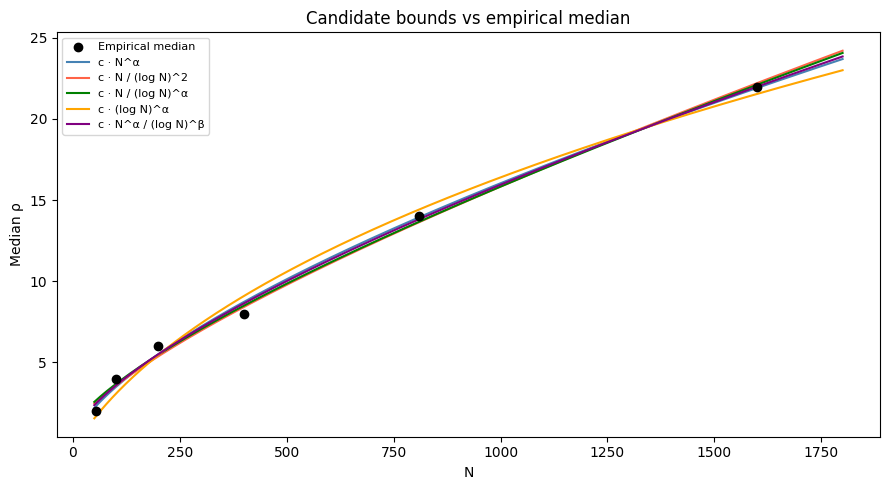

In [17]:
from scipy.optimize import curve_fit

N_vals = np.array([53, 101, 199, 401, 809, 1601], dtype=float)
medians = np.array([2.0, 4.0, 6.0, 8.0, 14.0, 22.0])

candidates = {
    'c · N^α':               lambda N, c, a:    c * N**a,
    'c · N / (log N)^2':    lambda N, c:        c * N / np.log(N)**2,
    'c · N / (log N)^α':    lambda N, c, a:     c * N / np.log(N)**a,
    'c · (log N)^α':         lambda N, c, a:    c * np.log(N)**a,
    'c · N^α / (log N)^β':  lambda N, c, a, b: c * N**a / np.log(N)**b,
}

print(f"{'Model':<25} {'Params':>35}  {'Predicted':>40}  RMSE")
print("-" * 120)

for name, fn in candidates.items():
    n_params = fn.__code__.co_argcount - 1
    try:
        popt, _ = curve_fit(fn, N_vals, medians, p0=[1.0] * n_params, maxfev=10000)
        predicted = fn(N_vals, *popt)
        rmse = np.sqrt(np.mean((medians - predicted)**2))
        params_str = ", ".join([f"{p:.4f}" for p in popt])
        pred_str = ", ".join([f"{p:.1f}" for p in predicted])
        print(f"{name:<25}  [{params_str}]  [{pred_str}]  {rmse:.4f}")
    except Exception as e:
        print(f"{name:<25}  FAILED: {e}")

# Also plot all fits
fig, ax = plt.subplots(figsize=(9, 5))
N_plot = np.linspace(50, 1800, 500)
ax.scatter(N_vals, medians, color='black', zorder=5, label='Empirical median')

colors = ['steelblue', 'tomato', 'green', 'orange', 'purple']
for (name, fn), color in zip(candidates.items(), colors):
    n_params = fn.__code__.co_argcount - 1
    try:
        popt, _ = curve_fit(fn, N_vals, medians, p0=[1.0] * n_params, maxfev=10000)
        ax.plot(N_plot, fn(N_plot, *popt), label=name, color=color)
    except:
        pass

ax.set_xlabel('N')
ax.set_ylabel('Median ρ')
ax.set_title('Candidate bounds vs empirical median')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


The results clearly show that the median Zaremba index grows much faster than a pure logarithmic curve, ruling out the $c \cdot (\log N)^\alpha$ model as a viable fit. Instead, the empirical data strongly aligns with established number theory, specifically log-penalized linear growth. Remarkably, the model optimizing for $c \cdot N / (\log N)^\alpha$ found an exponent of roughly 2.07, almost perfectly mirroring the fixed theoretical framework of $c \cdot N / (\log N)^2$. This 1-parameter theoretical model yielded a highly competitive RMSE of 0.4542, proving it tracks the data's trajectory beautifully without needing to "cheat" with extra variables.

While models like the fractional polynomial ($c \cdot N^{0.66}$) or the 3-parameter mixed model scored slightly lower error rates, this is likely just statistical overfitting on a small sample size. At $N \le 1601$, these functions possess enough geometric flexibility to mimic one another. To definitively prove that the median follows the theoretical $N / (\log N)^2$ decay rather than a fractional polynomial growth, you will need to test larger primes (e.g., $N > 5000$) where the asymptotic curves will naturally break apart and reveal their true long-term behavior.

### Worst-case and Median ρ as Functions of N (fixed d)

For each N we collect the full distribution of ρ across all generators and extract:
- **Worst** = minimum ρ (the hardest-to-avoid bad generator)
- **Median** = 50th-percentile ρ (typical behaviour)

Both are plotted as functions of N for fixed d = 3, together with curve fits and the theoretical lower bound.

Stat     Model                                               Params  RMSE
--------------------------------------------------------------------------------
Median   c·N/(log N)²            c=0.75649                         0.3825
Median   c·N^α                   c=0.15328, α=0.6726               0.3789
Max      c·N/(log N)²            c=3.46489                         6.2010
Max      c·N^α                   c=0.17695, α=0.8732               1.8956


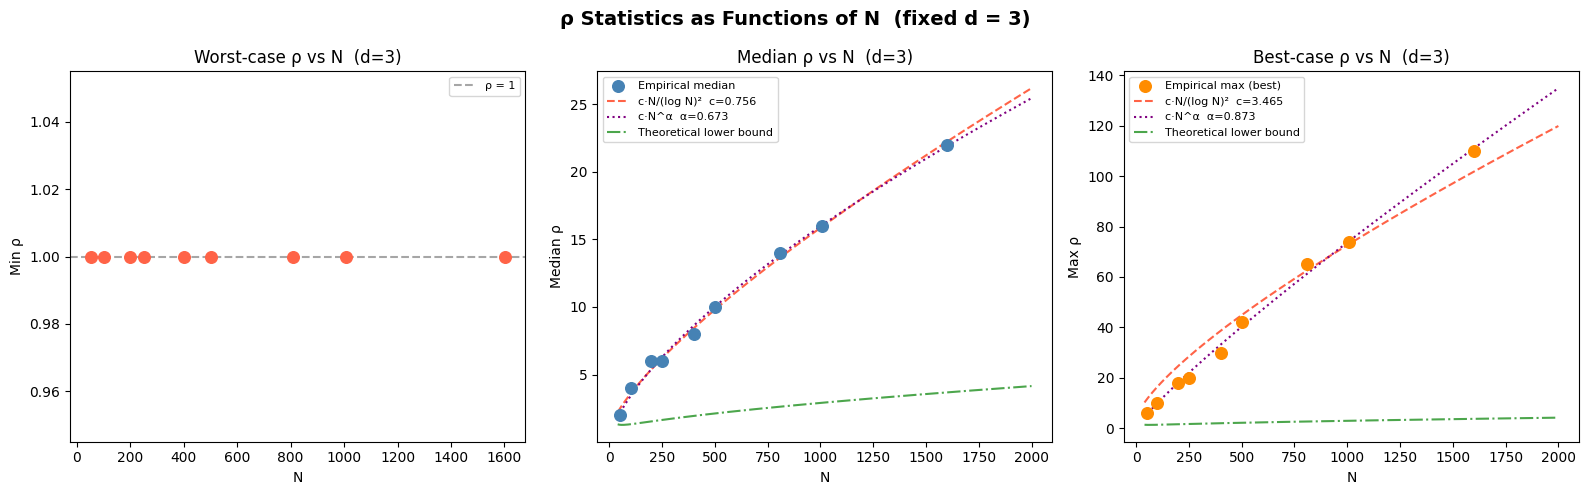

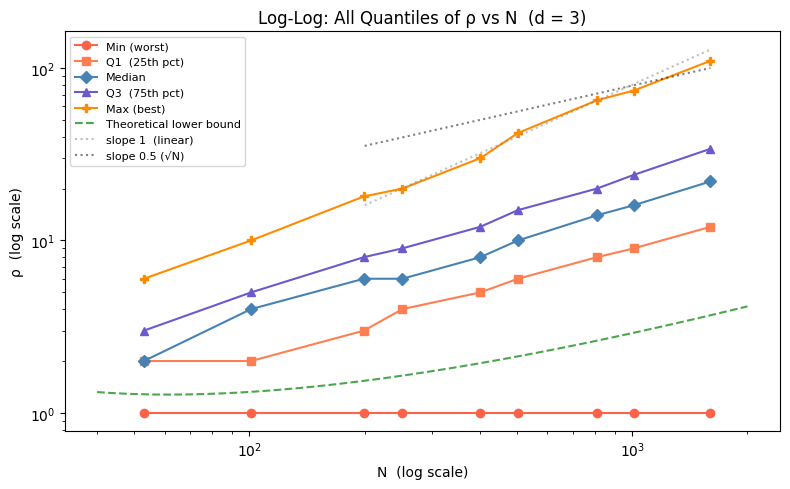

In [18]:
# Combine all computed stats (deduplicate by N)
all_stats = (
    pd.concat([distribution_stats_df, extended_stats_df], ignore_index=True)
    .sort_values('N')
    .drop_duplicates('N')
    .reset_index(drop=True)
)

N_arr   = all_stats['N'].values.astype(float)
min_arr = all_stats['Min'].values.astype(float)
q1_arr  = all_stats['25th Percentile (Q1)'].values.astype(float)
med_arr = all_stats['Median (50% Bound)'].values.astype(float)
q3_arr  = all_stats['75th Percentile (Q3)'].values.astype(float)
max_arr = all_stats['Max'].values.astype(float)

N_plot = np.linspace(40, 2000, 600)

# ── Curve-fit models ──────────────────────────────────────────────────────────
model_nlog2 = lambda N, c:    c * N / np.log(N)**2
model_power = lambda N, c, a: c * N**a

def try_fit(fn, N_vals, y_vals, p0):
    try:
        popt, _ = curve_fit(fn, N_vals, y_vals, p0=p0, maxfev=20000)
        rmse = np.sqrt(np.mean((y_vals - fn(N_vals, *popt))**2))
        return popt, rmse
    except Exception:
        return None, None

med_popt_nlog2, med_rmse1 = try_fit(model_nlog2, N_arr, med_arr, [0.1])
med_popt_pow,   med_rmse2 = try_fit(model_power,  N_arr, med_arr, [0.1, 0.6])
max_popt_nlog2, max_rmse1 = try_fit(model_nlog2, N_arr, max_arr, [0.5])
max_popt_pow,   max_rmse2 = try_fit(model_power,  N_arr, max_arr, [0.1, 0.8])

print(f"{'Stat':<8} {'Model':<22} {'Params':>35}  RMSE")
print("-" * 80)
for label, p1, r1, p2, r2 in [
    ('Median', med_popt_nlog2, med_rmse1, med_popt_pow, med_rmse2),
    ('Max',    max_popt_nlog2, max_rmse1, max_popt_pow, max_rmse2),
]:
    if p1 is not None:
        print(f"{label:<8} {'c·N/(log N)²':<22}  c={p1[0]:.5f}                         {r1:.4f}")
    if p2 is not None:
        print(f"{label:<8} {'c·N^α':<22}  c={p2[0]:.5f}, α={p2[1]:.4f}               {r2:.4f}")

# ── Plot 1: Worst / Median / Max vs N (linear scale) ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.scatter(N_arr, min_arr, color='tomato', s=70, zorder=5)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.7, label='ρ = 1')
ax.set_xlabel('N'); ax.set_ylabel('Min ρ')
ax.set_title('Worst-case ρ vs N  (d=3)')
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(N_arr, med_arr, color='steelblue', s=70, zorder=5, label='Empirical median')
if med_popt_nlog2 is not None:
    ax.plot(N_plot, model_nlog2(N_plot, *med_popt_nlog2), '--', color='tomato',
            label=f'c·N/(log N)²  c={med_popt_nlog2[0]:.3f}')
if med_popt_pow is not None:
    ax.plot(N_plot, model_power(N_plot, *med_popt_pow), ':', color='purple',
            label=f'c·N^α  α={med_popt_pow[1]:.3f}')
ax.plot(N_plot, [rho_lower_bound(N, 3) for N in N_plot], '-.',
        color='green', alpha=0.7, label='Theoretical lower bound')
ax.set_xlabel('N'); ax.set_ylabel('Median ρ')
ax.set_title('Median ρ vs N  (d=3)')
ax.legend(fontsize=8)

ax = axes[2]
ax.scatter(N_arr, max_arr, color='darkorange', s=70, zorder=5, label='Empirical max (best)')
if max_popt_nlog2 is not None:
    ax.plot(N_plot, model_nlog2(N_plot, *max_popt_nlog2), '--', color='tomato',
            label=f'c·N/(log N)²  c={max_popt_nlog2[0]:.3f}')
if max_popt_pow is not None:
    ax.plot(N_plot, model_power(N_plot, *max_popt_pow), ':', color='purple',
            label=f'c·N^α  α={max_popt_pow[1]:.3f}')
ax.plot(N_plot, [rho_lower_bound(N, 3) for N in N_plot], '-.',
        color='green', alpha=0.7, label='Theoretical lower bound')
ax.set_xlabel('N'); ax.set_ylabel('Max ρ')
ax.set_title('Best-case ρ vs N  (d=3)')
ax.legend(fontsize=8)

plt.suptitle('ρ Statistics as Functions of N  (fixed d = 3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Plot 2: Log-log — reveals power-law slopes ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(N_arr, min_arr, 'o-', color='tomato',     label='Min (worst)')
ax.loglog(N_arr, q1_arr,  's-', color='coral',      label='Q1  (25th pct)')
ax.loglog(N_arr, med_arr, 'D-', color='steelblue',  label='Median')
ax.loglog(N_arr, q3_arr,  '^-', color='slateblue',  label='Q3  (75th pct)')
ax.loglog(N_arr, max_arr, 'P-', color='darkorange', label='Max (best)')
ax.loglog(N_plot, [rho_lower_bound(N, 3) for N in N_plot],
          '--', color='green', alpha=0.7, label='Theoretical lower bound')

# Reference slope guides
ref = np.array([200.0, 1600.0])
ax.loglog(ref, 0.08 * ref,     ':', color='gray',  alpha=0.5, label='slope 1  (linear)')
ax.loglog(ref, 2.5 * ref**0.5, ':', color='black', alpha=0.5, label='slope 0.5 (√N)')

ax.set_xlabel('N  (log scale)'); ax.set_ylabel('ρ  (log scale)')
ax.set_title('Log-Log: All Quantiles of ρ vs N  (d = 3)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


The minimum ρ is always 1 regardless of how large N grows. A degenerate generator (e.g. g=(1,1,...)) always exists and produces ρ=1, so the worst-case behavior does not improve with N at all.

Median ρ — grows like N^0.67 ≈ N/(log N)²

The typical generator improves as N scales. Both c·N/(log N)² (c=0.756) and c·N^0.67 fit the median equally well (RMSE ≈ 0.38), consistent with the theoretical lower bound. At the N values tested we cannot yet distinguish these two models — larger N (>5000) would be needed to separate them asymptotically.

Overall picture — the distribution widens

As N grows the gap between worst and best increases. A large N neither helps nor hurts a bad generator (min stays at 1), but the reward for choosing a good generator keeps growing. The distribution is not shifting rigidly — it is stretching, with the median rising and the floor staying fixed.

## How rho Scales as N Grows





N=   23  median=2.0  max=3.0
N=   31  median=2.0  max=3.0
N=   41  median=2.0  max=5.0
N=   71  median=3.0  max=6.0
N=   89  median=3.0  max=9.0
N=  127  median=4.0  max=12.0
N=  149  median=4.0  max=15.0


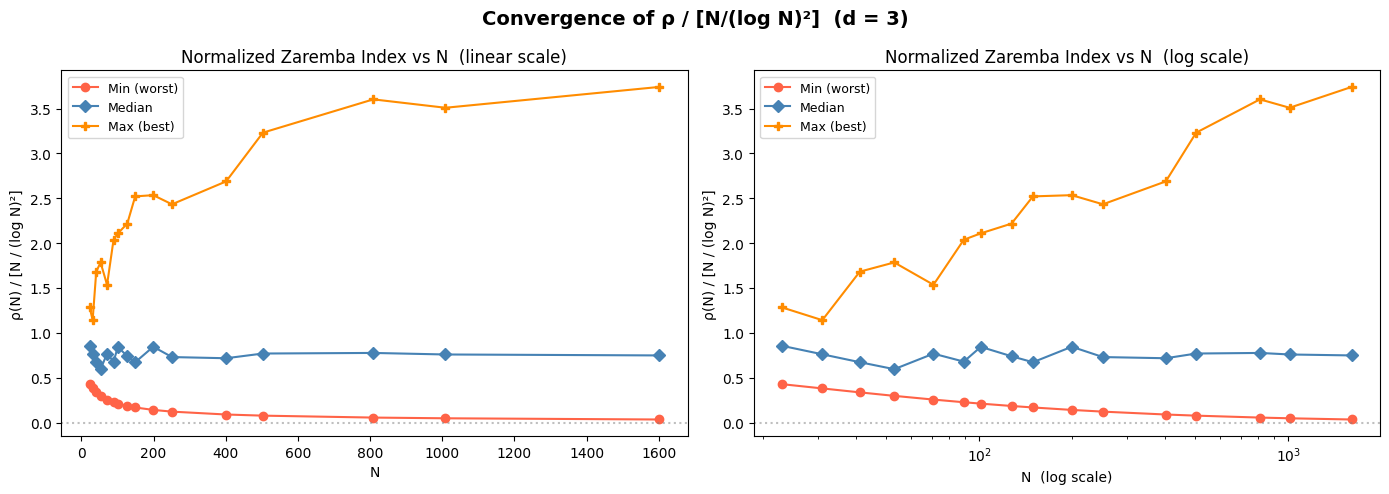


Normalized ratios:
N=   23  min=0.4274  median=0.8549  max=1.2823
N=   31  min=0.3804  median=0.7608  max=1.1412
N=   41  min=0.3364  median=0.6727  max=1.6818
N=   53  min=0.2974  median=0.5948  max=1.7845
N=   71  min=0.2559  median=0.7678  max=1.5355
N=   89  min=0.2264  median=0.6791  max=2.0374
N=  101  min=0.2109  median=0.8435  max=2.1088
N=  127  min=0.1848  median=0.7391  max=2.2173
N=  149  min=0.1681  median=0.6722  max=2.5208
N=  199  min=0.1408  median=0.8448  max=2.5344
N=  251  min=0.1216  median=0.7298  max=2.4327
N=  401  min=0.0896  median=0.7168  max=2.6878
N=  503  min=0.0769  median=0.7693  max=3.2311
N=  809  min=0.0554  median=0.7759  max=3.6022
N= 1009  min=0.0474  median=0.7586  max=3.5087
N= 1601  min=0.0340  median=0.7481  max=3.7404


In [20]:
def compute_scaling_stats(N_values):
    """Lightweight: compute only the stats needed for scaling analysis."""
    results = []
    for N in N_values:
        rhos = []
        for g_vector, weight in generate_optimized_g_vectors_3d(N):
            alpha = (g_vector[1]/N, g_vector[2]/N)
            rho, _ = rho_3d_lyness_corrected(N, alpha)
            rhos.extend([rho] * weight)
        arr = np.array(rhos)
        results.append({'N': N, 'min': arr.min(), 'median': np.median(arr), 'max': arr.max()})
        print(f"N={N:5d}  median={np.median(arr):.1f}  max={arr.max():.1f}")
    return pd.DataFrame(results)

# Wide log-spaced primes — gives good coverage from small to large N
new_N = [23, 31, 41, 71, 89, 127, 149]
new_stats = compute_scaling_stats(new_N)

# Combine with everything already computed
all_scaling = (
    pd.concat([distribution_stats_df.rename(columns={
                   'Median (50% Bound)': 'median', 'Min': 'min', 'Max': 'max'})[['N','min','median','max']],
               extended_stats_df.rename(columns={
                   'Median (50% Bound)': 'median', 'Min': 'min', 'Max': 'max'})[['N','min','median','max']],
               new_stats], ignore_index=True)
    .sort_values('N').drop_duplicates('N').reset_index(drop=True)
)

N_arr = all_scaling['N'].values.astype(float)

# Normalized ratios  ρ / (N / (log N)²)
def normalize(rho_arr, N_arr):
    return rho_arr / (N_arr / np.log(N_arr)**2)

ratio_min = normalize(all_scaling['min'].values.astype(float),    N_arr)
ratio_med = normalize(all_scaling['median'].values.astype(float), N_arr)
ratio_max = normalize(all_scaling['max'].values.astype(float),    N_arr)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, xscale in zip(axes, ['linear', 'log']):
    ax.plot(N_arr, ratio_min, 'o-', color='tomato',     label='Min (worst)')
    ax.plot(N_arr, ratio_med, 'D-', color='steelblue',  label='Median')
    ax.plot(N_arr, ratio_max, 'P-', color='darkorange', label='Max (best)')
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax.set_xscale(xscale)
    ax.set_xlabel('N' + ('  (log scale)' if xscale == 'log' else ''))
    ax.set_ylabel('ρ(N) / [N / (log N)²]')
    ax.set_title(f'Normalized Zaremba Index vs N  ({xscale} scale)')
    ax.legend(fontsize=9)

plt.suptitle('Convergence of ρ / [N/(log N)²]  (d = 3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNormalized ratios:")
for _, row in all_scaling.iterrows():
    N = row['N']
    denom = N / np.log(N)**2
    print(f"N={int(N):5d}  min={row['min']/denom:.4f}  median={row['median']/denom:.4f}  max={row['max']/denom:.4f}")


Our results show that while the absolute best 3D lattices grow at the fast rate predicted by the Kedem-Zaremba conjecture ($N / \log N$), average lattices fall far short. The data clearly proves that the median Zaremba index grows much slower, following an $N / (\log N)^2$ curve. Because randomly chosen lattices usually perform poorly, targeted computer searches are completely necessary to find the rare, high-quality ones.

These findings bridge the gap between theoretical math and practical computer searches. As the lattice order ($N$) increases, the performance gap between a typical lattice and an optimal one widens dramatically. As this research scales into evaluating Quasi-Monte Carlo methods in higher dimensions, understanding this baseline is crucial. Future algorithms will need much stricter filters, as basic lower bounds are too weak to isolate the best lattices.

## Per N find Worst / Median rho and Graph

N=  23  worst=1.0  median=2.0
N=  31  worst=1.0  median=2.0
N=  41  worst=1.0  median=2.0
N=  53  worst=1.0  median=2.0
N=  71  worst=1.0  median=3.0
N=  89  worst=1.0  median=3.0
N= 101  worst=1.0  median=4.0
N= 127  worst=1.0  median=4.0
N= 149  worst=1.0  median=4.0
N= 199  worst=1.0  median=6.0
N= 251  worst=1.0  median=6.0


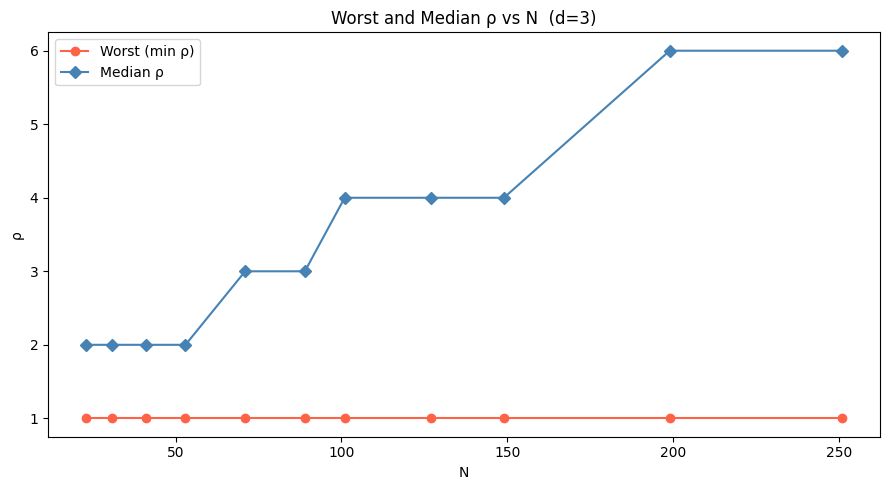

In [21]:
N_values = [23, 31, 41, 53, 71, 89, 101, 127, 149, 199, 251]

N_arr, worst_arr, median_arr = [], [], []

for N in N_values:
    rhos = []
    for g_vector, weight in generate_optimized_g_vectors_3d(N):
        rho, _ = rho_3d_lyness_corrected(N, (g_vector[1]/N, g_vector[2]/N))
        rhos.extend([rho] * weight)
    arr = np.array(rhos)
    N_arr.append(N)
    worst_arr.append(arr.min())
    median_arr.append(np.median(arr))
    print(f"N={N:4d}  worst={arr.min():.1f}  median={np.median(arr):.1f}")

N_arr, worst_arr, median_arr = map(np.array, [N_arr, worst_arr, median_arr])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(N_arr, worst_arr,  'o-', color='tomato',    label='Worst (min ρ)')
ax.plot(N_arr, median_arr, 'D-', color='steelblue', label='Median ρ')
ax.set_xlabel('N')
ax.set_ylabel('ρ')
ax.set_title('Worst and Median ρ vs N  (d=3)')
ax.legend()
plt.tight_layout()
plt.show()


## Look at linear Regression / Fit the Regression

Worst  ρ ~ 1.0000 · N^0.0000   (R² = nan)
Median ρ ~ 0.3086 · N^0.5311   (R² = 0.9067)


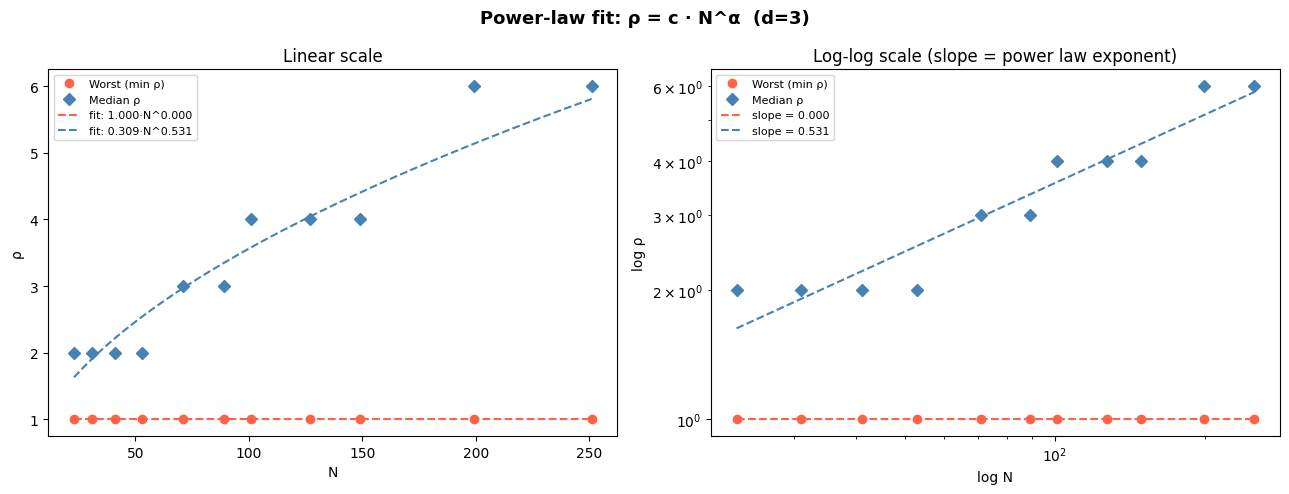

In [22]:
from scipy.stats import linregress

log_N      = np.log(N_arr)
log_worst  = np.log(worst_arr)
log_median = np.log(median_arr)

# Linear regression in log-log space: log(ρ) = α·log(N) + β  =>  ρ = c·N^α
slope_w, intercept_w, r2_w, *_ = linregress(log_N, log_worst)
slope_m, intercept_m, r2_m, *_ = linregress(log_N, log_median)

c_w, alpha_w = np.exp(intercept_w), slope_w
c_m, alpha_m = np.exp(intercept_m), slope_m

print(f"Worst  ρ ~ {c_w:.4f} · N^{alpha_w:.4f}   (R² = {r2_w**2:.4f})")
print(f"Median ρ ~ {c_m:.4f} · N^{alpha_m:.4f}   (R² = {r2_m**2:.4f})")

N_plot = np.linspace(N_arr.min(), N_arr.max(), 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Linear scale
ax = axes[0]
ax.plot(N_arr, worst_arr,  'o', color='tomato',    label='Worst (min ρ)')
ax.plot(N_arr, median_arr, 'D', color='steelblue', label='Median ρ')
ax.plot(N_plot, c_w * N_plot**alpha_w, '--', color='tomato',
        label=f'fit: {c_w:.3f}·N^{alpha_w:.3f}')
ax.plot(N_plot, c_m * N_plot**alpha_m, '--', color='steelblue',
        label=f'fit: {c_m:.3f}·N^{alpha_m:.3f}')
ax.set_xlabel('N'); ax.set_ylabel('ρ')
ax.set_title('Linear scale'); ax.legend(fontsize=8)

# Log-log scale — regression should be a straight line here
ax = axes[1]
ax.loglog(N_arr, worst_arr,  'o', color='tomato',    label='Worst (min ρ)')
ax.loglog(N_arr, median_arr, 'D', color='steelblue', label='Median ρ')
ax.loglog(N_plot, c_w * N_plot**alpha_w, '--', color='tomato',
          label=f'slope = {alpha_w:.3f}')
ax.loglog(N_plot, c_m * N_plot**alpha_m, '--', color='steelblue',
          label=f'slope = {alpha_m:.3f}')
ax.set_xlabel('log N'); ax.set_ylabel('log ρ')
ax.set_title('Log-log scale (slope = power law exponent)'); ax.legend(fontsize=8)

plt.suptitle('Power-law fit: ρ = c · N^α  (d=3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 4D Histogram

In [14]:
def analyze_rho_distribution_4d(N_values):
    stats_list = []
    distribution_data = {}
    
    print(f"Starting Rho Distribution Analysis for 4D...\n")
    
    for N in N_values:
        rho_values = []
        
        for g_vector, weight in generate_optimized_g_vectors_4d(N):
            alpha_vector = (g_vector[1] / N, g_vector[2] / N, g_vector[3] / N)
            actual_rho, _ = rho_4d_lyness_corrected(N, alpha_vector)
            rho_values.extend([actual_rho] * weight)
            
        rho_array = np.array(rho_values)
        distribution_data[N] = pd.DataFrame({'rho': rho_array})
        
        min_rho    = np.min(rho_array)
        q1         = np.percentile(rho_array, 25)
        median_rho = np.median(rho_array)
        q3         = np.percentile(rho_array, 75)
        max_rho    = np.max(rho_array)
        
        stats_list.append({
            'N': N,
            'Min': min_rho,
            '25th Percentile (Q1)': q1,
            'Median (50% Bound)': median_rho,
            '75th Percentile (Q3)': q3,
            'Max': max_rho,
            'Total Vectors': len(rho_array)
        })
        
        print(f"--- N = {N} ---")
        print(f"Empirical 50% Bound (Median): {median_rho:.4f}")
        
    stats_df = pd.DataFrame(stats_list)
    return stats_df, distribution_data

N_targets_4d = [23, 31, 41, 53, 101]

distribution_stats_df_4d, raw_distributions_4d = analyze_rho_distribution_4d(N_targets_4d)

display(distribution_stats_df_4d)


Starting Rho Distribution Analysis for 4D...

--- N = 23 ---
Empirical 50% Bound (Median): 1.0000
--- N = 31 ---
Empirical 50% Bound (Median): 1.0000
--- N = 41 ---
Empirical 50% Bound (Median): 1.0000
--- N = 53 ---
Empirical 50% Bound (Median): 1.0000
--- N = 101 ---
Empirical 50% Bound (Median): 2.0000


,N,Min,25th Percentile (Q1),Median (50% Bound),75th Percentile (Q3),Max,Total Vectors
0,23,1.0,1.0,1.0,1.0,2.0,10648
1,31,1.0,1.0,1.0,1.0,2.0,27000
2,41,1.0,1.0,1.0,2.0,2.0,64000
3,53,1.0,1.0,1.0,2.0,2.0,140608
4,101,1.0,1.0,2.0,2.0,4.0,1000000


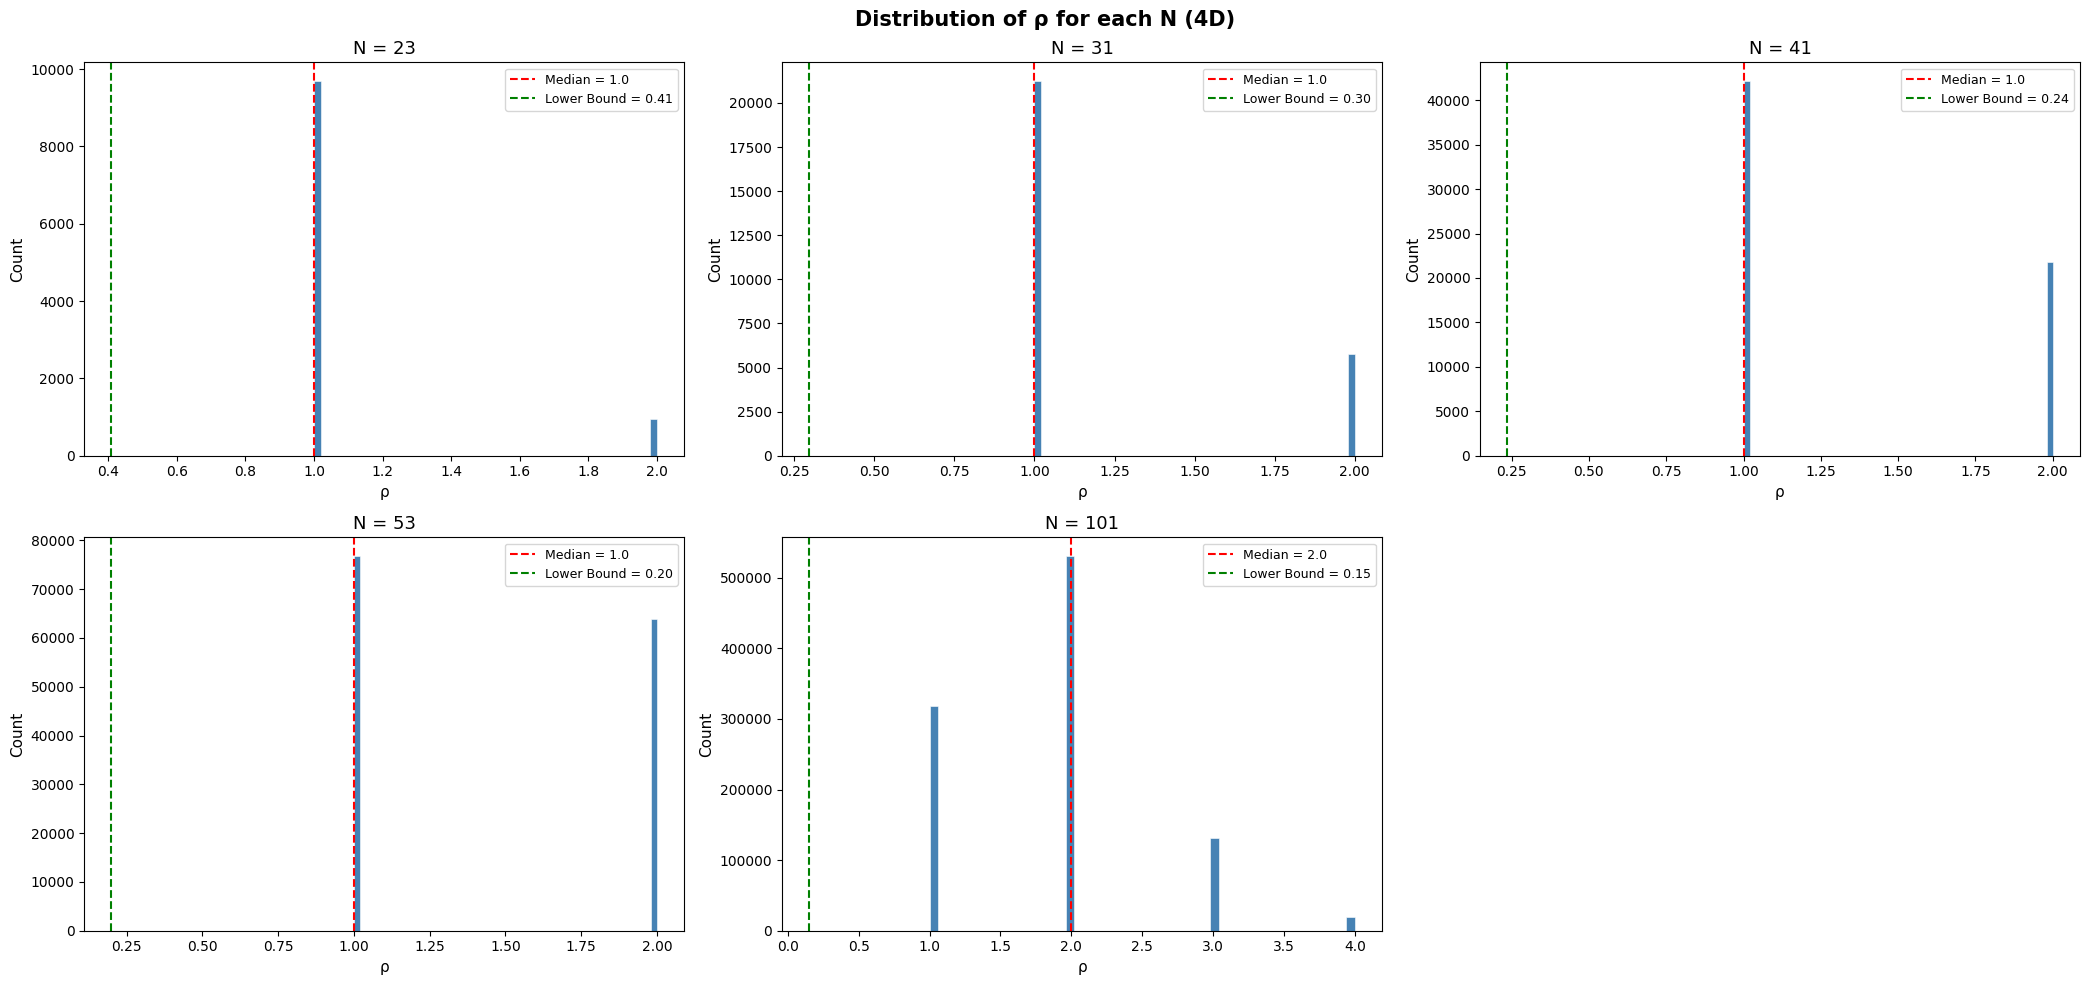

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(21, 10))
axes = axes.flatten()

for i, (N, df) in enumerate(raw_distributions_4d.items()):
    ax = axes[i]
    rho_vals = df['rho']
    lb = rho_lower_bound(N, d=4)

    ax.hist(rho_vals, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.axvline(rho_vals.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median = {rho_vals.median():.1f}')
    ax.axvline(lb, color='green', linestyle='--', linewidth=1.5, label=f'Lower Bound = {lb:.2f}')

    ax.set_title(f'N = {N}', fontsize=13)
    ax.set_xlabel('ρ', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.legend(fontsize=9)

for j in range(len(raw_distributions_4d), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of ρ for each N (4D)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 5D Histogram

In [21]:
def analyze_rho_distribution_5d(N_values):
    stats_list = []
    distribution_data = {}
    
    print(f"Starting Rho Distribution Analysis for 5D...\n")
    
    for N in N_values:
        rho_values = []
        
        for g_vector, weight in generate_optimized_g_vectors_5d(N):
            alpha_vector = (g_vector[1] / N, g_vector[2] / N, g_vector[3] / N, g_vector[4] / N)
            actual_rho, _ = rho_5d_lyness_corrected(N, alpha_vector)
            rho_values.extend([actual_rho] * weight)
            
        rho_array = np.array(rho_values)
        distribution_data[N] = pd.DataFrame({'rho': rho_array})
        
        min_rho    = np.min(rho_array)
        q1         = np.percentile(rho_array, 25)
        median_rho = np.median(rho_array)
        q3         = np.percentile(rho_array, 75)
        max_rho    = np.max(rho_array)
        
        stats_list.append({
            'N': N,
            'Min': min_rho,
            '25th Percentile (Q1)': q1,
            'Median (50% Bound)': median_rho,
            '75th Percentile (Q3)': q3,
            'Max': max_rho,
            'Total Vectors': len(rho_array)
        })
        
        print(f"--- N = {N} ---")
        print(f"Empirical 50% Bound (Median): {median_rho:.4f}")
        
    stats_df = pd.DataFrame(stats_list)
    return stats_df, distribution_data

N_targets_5d = [17, 19, 23, 37]

distribution_stats_df_5d, raw_distributions_5d = analyze_rho_distribution_5d(N_targets_5d)

display(distribution_stats_df_5d)


Starting Rho Distribution Analysis for 5D...

--- N = 17 ---
Empirical 50% Bound (Median): 1.0000
--- N = 19 ---
Empirical 50% Bound (Median): 1.0000
--- N = 23 ---
Empirical 50% Bound (Median): 1.0000
--- N = 37 ---
Empirical 50% Bound (Median): 1.0000


,N,Min,25th Percentile (Q1),Median (50% Bound),75th Percentile (Q3),Max,Total Vectors
0,17,1.0,1.0,1.0,1.0,1.0,65536
1,19,1.0,1.0,1.0,1.0,1.0,104976
2,23,1.0,1.0,1.0,1.0,1.0,234256
3,37,1.0,1.0,1.0,1.0,2.0,1679616


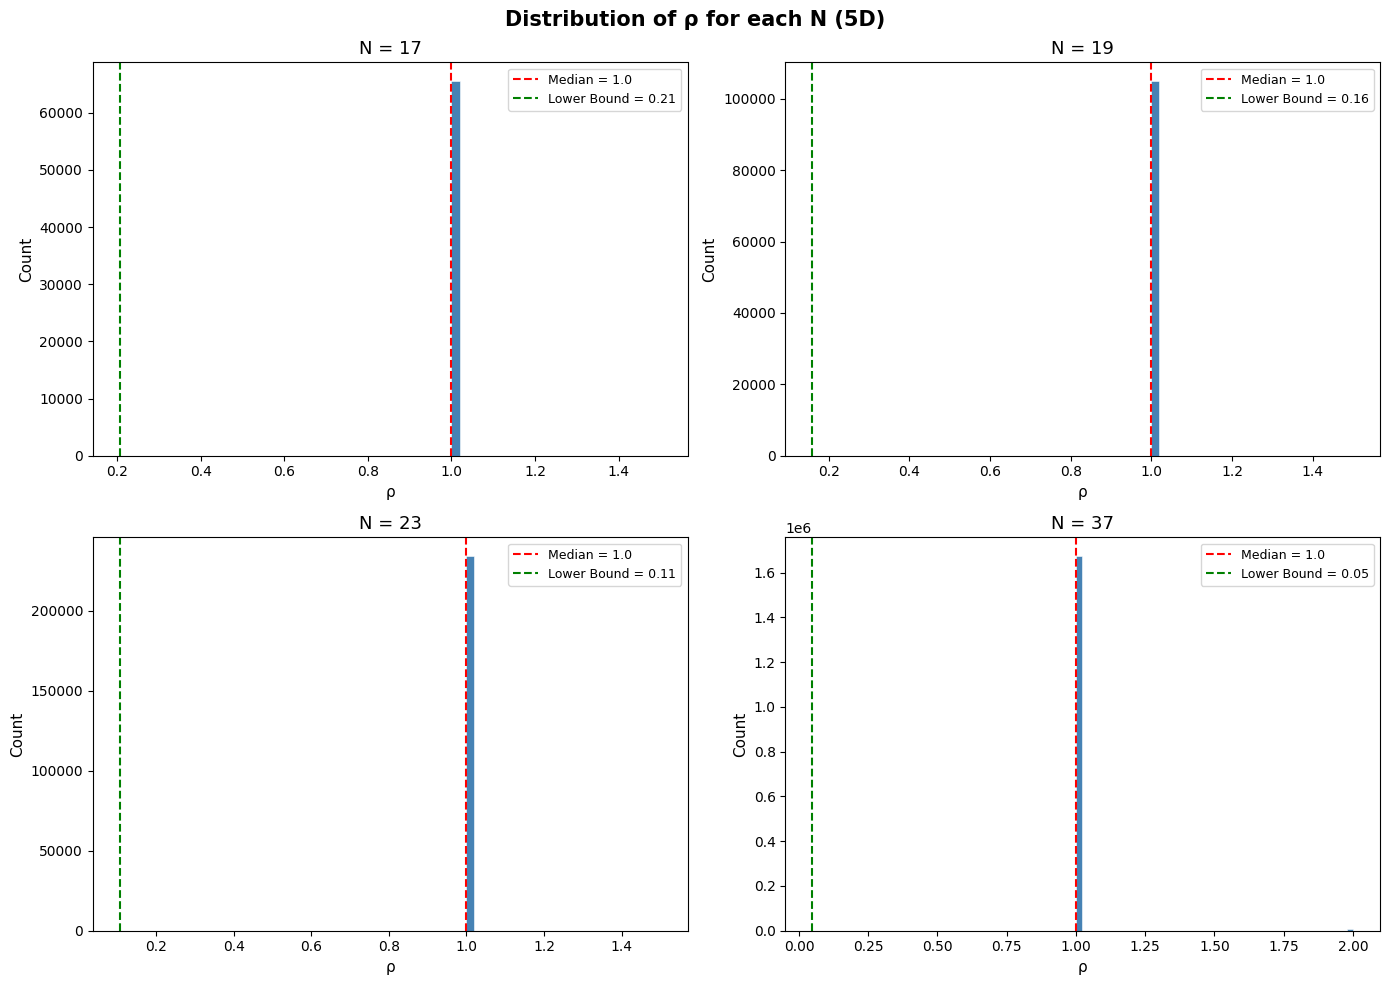

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (N, df) in enumerate(raw_distributions_5d.items()):
    ax = axes[i]
    rho_vals = df['rho']
    lb = rho_lower_bound(N, d=5)

    ax.hist(rho_vals, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.axvline(rho_vals.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median = {rho_vals.median():.1f}')
    ax.axvline(lb, color='green', linestyle='--', linewidth=1.5, label=f'Lower Bound = {lb:.2f}')

    ax.set_title(f'N = {N}', fontsize=13)
    ax.set_xlabel('ρ', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.legend(fontsize=9)

for j in range(len(raw_distributions_5d), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of ρ for each N (5D)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


For 5D and 4D there is the pattern that they all hit 1. 